Dataset: Loan Prediction Dataset

Source: https://huggingface.co/datasets/Ravichandrachilde/loan-prediction-dataset

Objective: Predict whether a loan will be approved (Y) or rejected (N)

Algorithms Used:

- Logistic Regression - Probabilistic model for binary classification
- Decision Tree - Tree-based model with interpretable decision paths
- Random Forest - Ensemble method combining multiple decision trees

### 1. Importing Required Libraries

- pandas: Used for data manipulation and analysis using DataFrame structures
- numpy: Used for mathematical functions
- matplotlib.pyplot: the standard library for creating static, interactive, and animated visualizations
- seaborn: A statistical data visualization library based on matplotlib that provides a high-level interface for drawing attractive graphics
- scipy.stats (chi2_contingency): Used for hypothesis testing to find significant relationships between features
- sklearn.model_selection (train_test_split, GridSearchCV, cross_val_score): Tools for splitting data, tuning hyperparameters, and cross-validating models
- sklearn.preprocessing (LabelEncoder, StandardScaler): Used to encode categorical text and scale numerical values for better model performance
- sklearn.linear_model (LogisticRegression): A linear model used for binary classification tasks
- sklearn.tree (DecisionTreeClassifier, plot_tree): A non-linear model that uses a tree-like graph of decisions
- sklearn.ensemble (RandomForestClassifier): An ensemble method that uses multiple decision trees to improve predictive accuracy
- sklearn.metrics: A comprehensive suite of toolsused to evaluate model performance
- imblearn.over_sampling (SMOTE): Used to handle class imbalance by generating synthetic samples of the minority class

In [1050]:
# Import Required Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, f_oneway

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, roc_curve, auc, 
                             roc_auc_score)

### 2. Exploratory Data Analysis (EDA)
- In this phase, the dataset is analyzed to discover patterns, detect outliers, and check for missing values

#### 2.1. Data Inspection

In [1051]:
# Data Loading
df = pd.read_csv('loan_prediction.csv')

In [1052]:
# Display column names to understand available features
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [1053]:
# Check the shape to see the volume of data
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Check data info
print("\nDataset info:")
df.info()


Dataset shape: (614, 13)

First few rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0       

In [1054]:
# Statistical Summary
# Descriptive statistics for numerical columns to identify outliers and distributions
df.describe()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [1055]:
# Check missing values
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values:
Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64


In [1056]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")


Duplicate Rows: 0


#### Data Inspection Summary

- Feature Overview: The dataset contains 13 columns, and target Loan_Status
- Data Volume: There are 614 records, providing a solid foundation for training classification algorithms
- Variable Types: The data is composed of 8 categorical features and 5 numerical features, requiring both encoding and scaling
- Skewness Detection: A large variance between mean and maximum income values indicates significant right-skewness and outliers
- Missing Data: Seven variables contain null values, with Credit_History and Self_Employed having the highest missing counts
- Data Uniqueness: there are zero duplicate rows, ensuring that each loan application is unique and wont bias the model through repetition
- Class ImBalance: Initial inspection reveals a 70/30 split between approvals and rejections, suggesting a need for balancing techniques

In [1057]:
# Identify numeric and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nThe numerical columns are: {numeric_cols}")
print(f"\nThe categorical columns are: {categorical_cols}")


The numerical columns are: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

The categorical columns are: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


In [1058]:
# Check missing values
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values:
Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64


#### 2.2. Univariate Analysis
- It is the simplest from of analyzing data where each variable is examined individually


#### Target Variable
- Loan_Status

In [1059]:
df['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [1060]:

# Check the percentage distribution to identify class imbalance
df['Loan_Status'].value_counts(normalize=True)

Loan_Status
Y    0.687296
N    0.312704
Name: proportion, dtype: float64

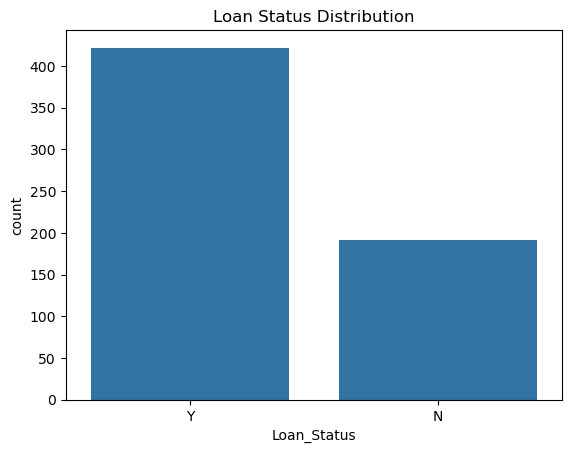

In [1061]:
# Visualizes the distribution of the target variable
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Status Distribution")
plt.show()


- Class Distribution: The dataset contains 422 approved loans (Y) and 192 rejected loans (N)
- Proportion Analysis: Approximately 68.7% of applications in the dataset were approved, while 31.3% were rejected
- Imbalance Detection: There is a significant class imbalance , indicating the model may naturally favor the majority class without balancing techniques like SMOTE

#### Independent Variable(Categorical)

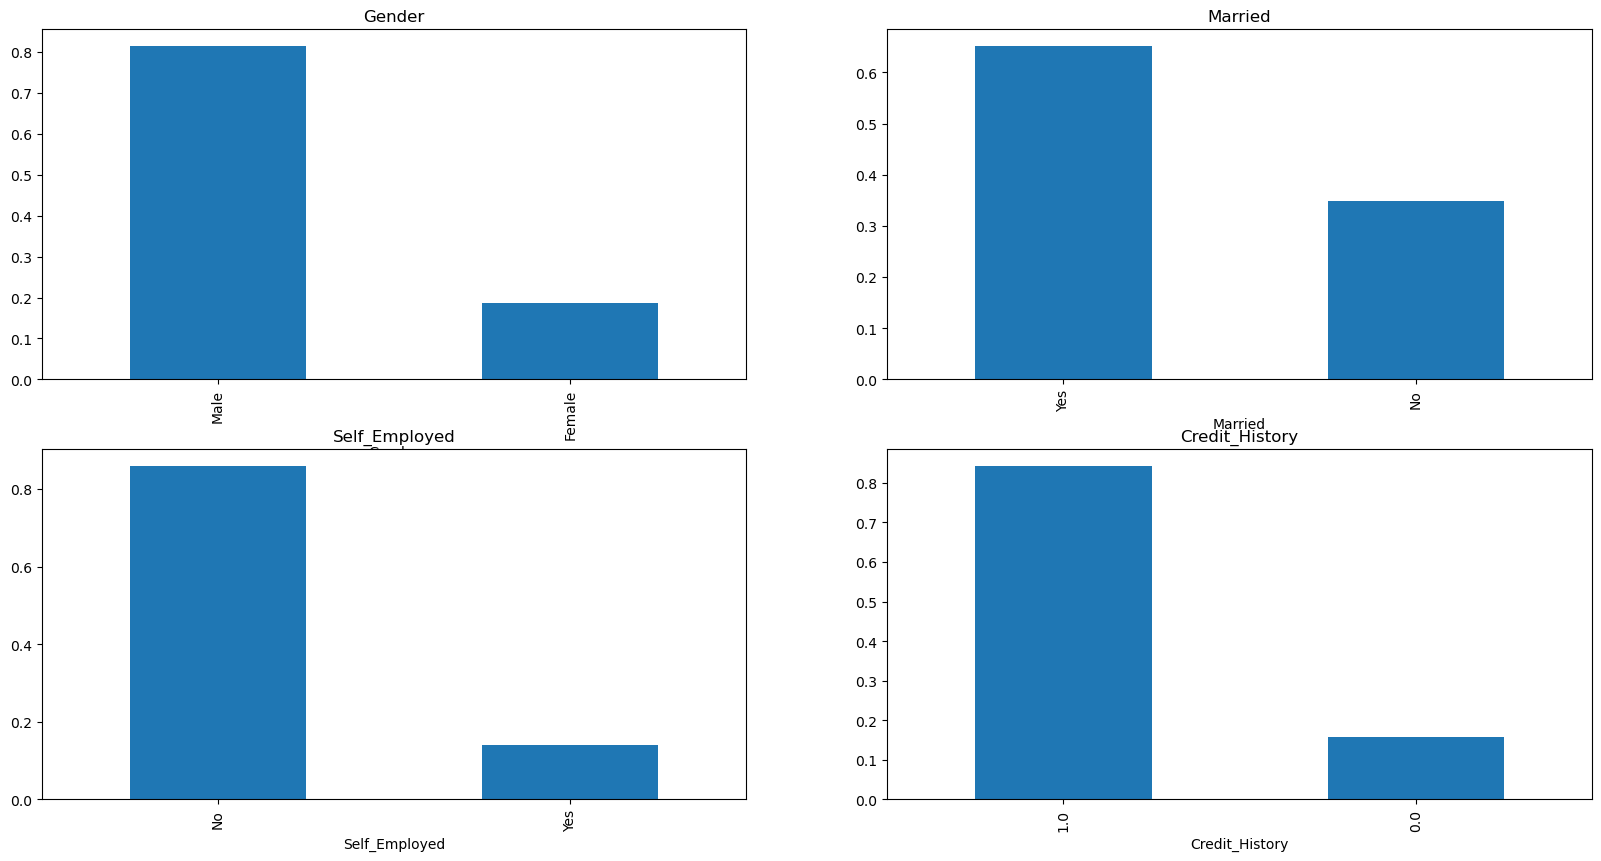

In [1062]:
plt.figure(1)
plt.subplot(221)
df['Gender'].value_counts(normalize=True).plot.bar(figsize=(20,10), title= 'Gender') 
plt.subplot(222) 
df['Married'].value_counts(normalize=True).plot.bar(title= 'Married') 
plt.subplot(223) 
df['Self_Employed'].value_counts(normalize=True).plot.bar(title= 'Self_Employed') 
plt.subplot(224) 
df['Credit_History'].value_counts(normalize=True).plot.bar(title= 'Credit_History') 
plt.show()

It can be inferred from the above bar plots that:
- 80% applicants in the dataset are male
- Around 65% of the applicants in the dataset are married
- Around 15% applicants in the dataset are self employed
- Around 85% applicants have repaid their debts

#### Independent Variable(Ordinal)

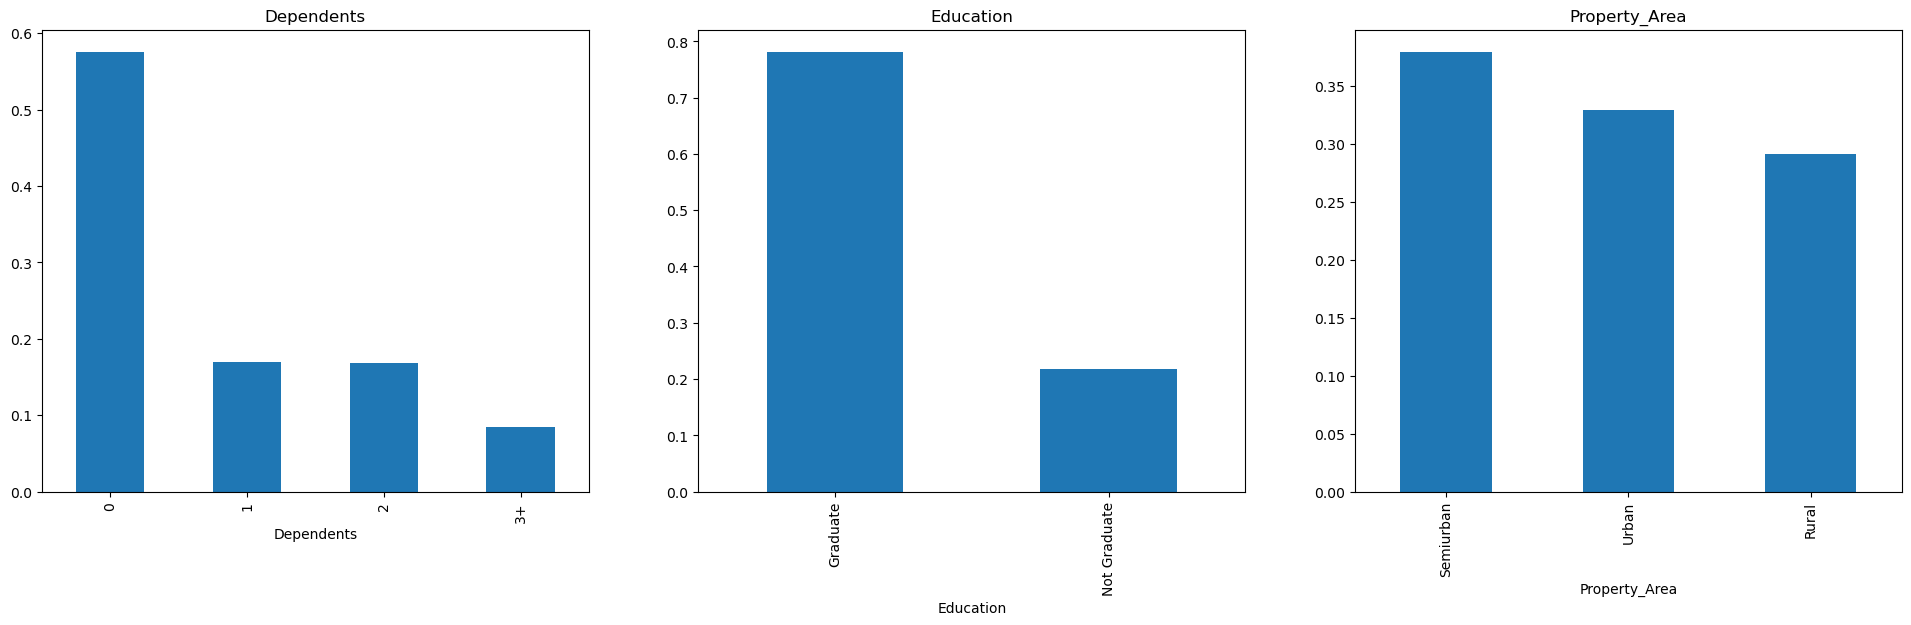

In [1063]:
plt.figure(1)
plt.subplot(131) 
df['Dependents'].value_counts(normalize=True).plot.bar(figsize=(24,6), title= 'Dependents') 
plt.subplot(132) 
df['Education'].value_counts(normalize=True).plot.bar(title= 'Education') 
plt.subplot(133) 
df['Property_Area'].value_counts(normalize=True).plot.bar(title= 'Property_Area') 
plt.show()

Following inferences can be made from the above bar plots: 
- Most of the applicants don’t have any dependents
-  Around 80% of the applicants are Graduate
-  Most of the applicants are from Semiurban area

#### Independent Variable (Numerical)

##### ApplicantIncome

C:\Users\Dell\AppData\Local\Temp\ipykernel_10260\240369579.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['ApplicantIncome']);


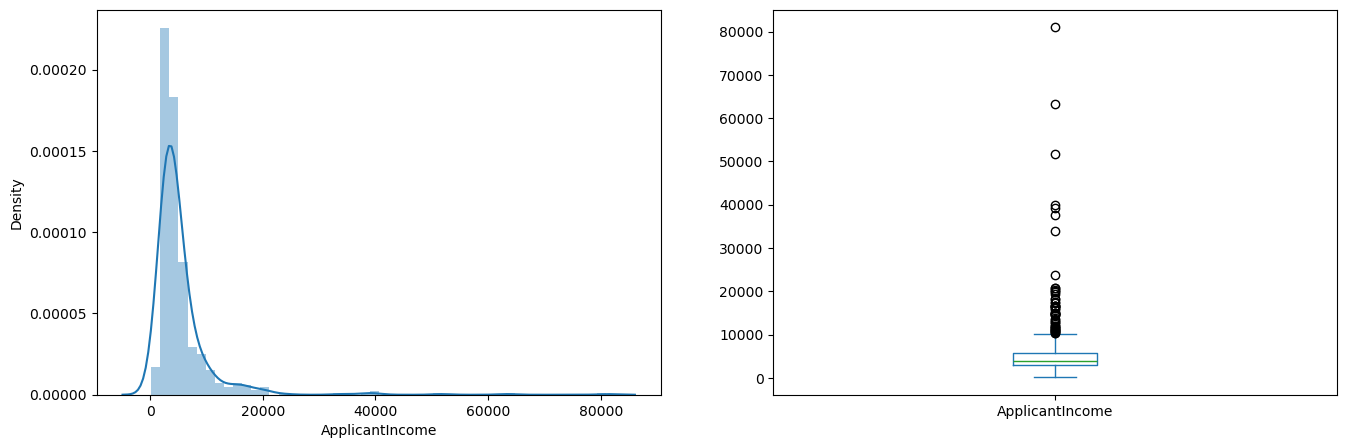

In [1064]:
plt.figure(1) 
plt.subplot(121) 
sns.distplot(df['ApplicantIncome']); 
plt.subplot(122) 
df['ApplicantIncome'].plot.box(figsize=(16,5)) 
plt.show()

- It can be concluded that most of the data in the distribution of applicant income is towards left, which means it is not normally distributed
- The boxplot confirms the presence of a lot of outliers/extreme values

##### ApplicantIncome by Education

Text(0.5, 0.98, '')

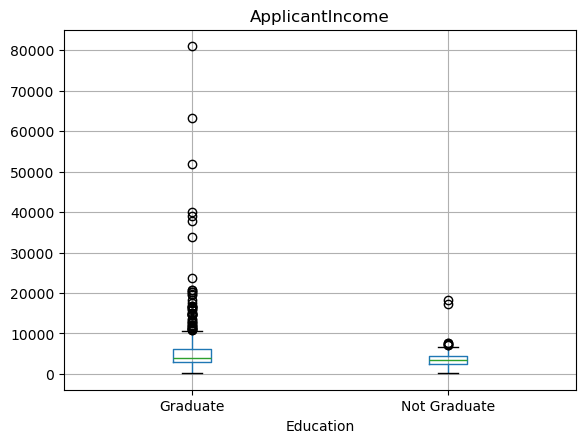

In [1065]:
df.boxplot(column='ApplicantIncome', by = 'Education') 
plt.suptitle("") 

- There are a higher number of graduates with very high incomes, which are appearing to be the outliers

##### CoapplicantIncome

C:\Users\Dell\AppData\Local\Temp\ipykernel_10260\196801975.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['CoapplicantIncome']);


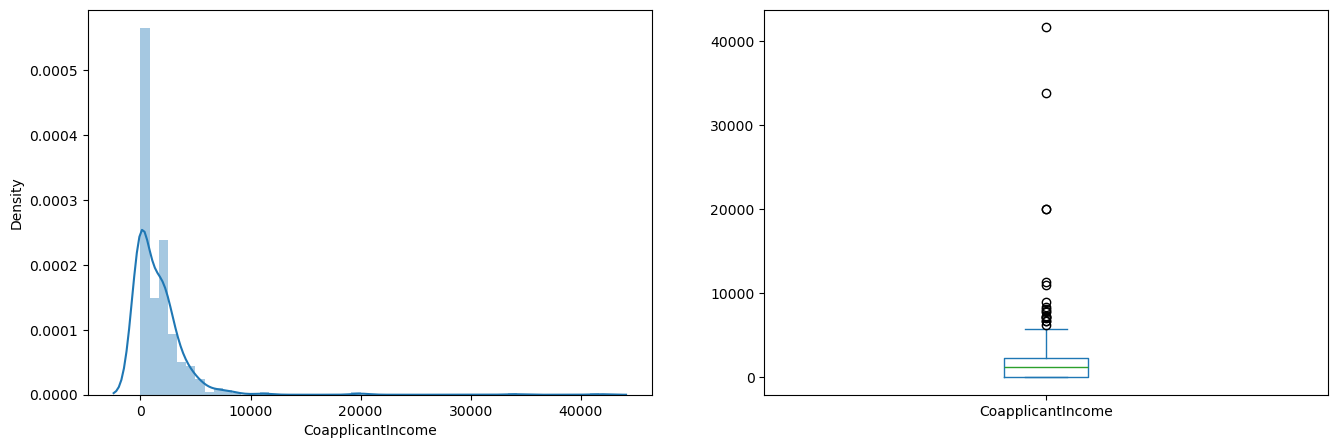

In [1066]:
# CoapplicantIncome Distribution
plt.figure(1)
plt.subplot(121)
sns.distplot(df['CoapplicantIncome']); 
plt.subplot(122) 
df['CoapplicantIncome'].plot.box(figsize=(16,5)) 
plt.show()

- A lot of outliers in the coapplicant income can be seen and it is not normally distributed

##### LoanAmount

C:\Users\Dell\AppData\Local\Temp\ipykernel_10260\1300148444.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_10260\1300148444.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use th

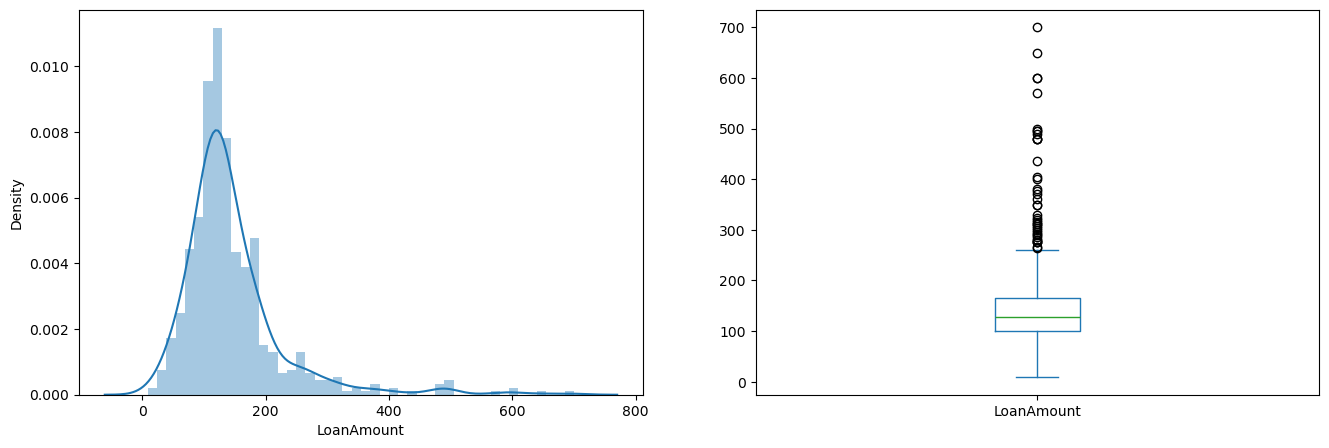

In [1067]:
plt.figure(1) 
plt.subplot(121) 
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
sns.distplot(df['LoanAmount']); 
plt.subplot(122) 
df['LoanAmount'].plot.box(figsize=(16,5)) 
plt.show()

- It can be seen that a lot of outliers is present in this variable and the distribution is fairly normal 

#### 2.3. Bivariate Analysis
This Hypothesis were generated earlier: 
- Applicants with high income should have more chances of loan approval
- Applicants who have repaid their previous debts should have higher chances of loan approval
- Loan approval should also depend on the loan amount. If the loan amount is less, chances of loan approval should be high
- Lesser the amount to be paid monthly to repay the loan, higher the chances of loan approval
  
This are to be tested using bivariate analysis


#### Categorical Independent Variable vs Target Variable

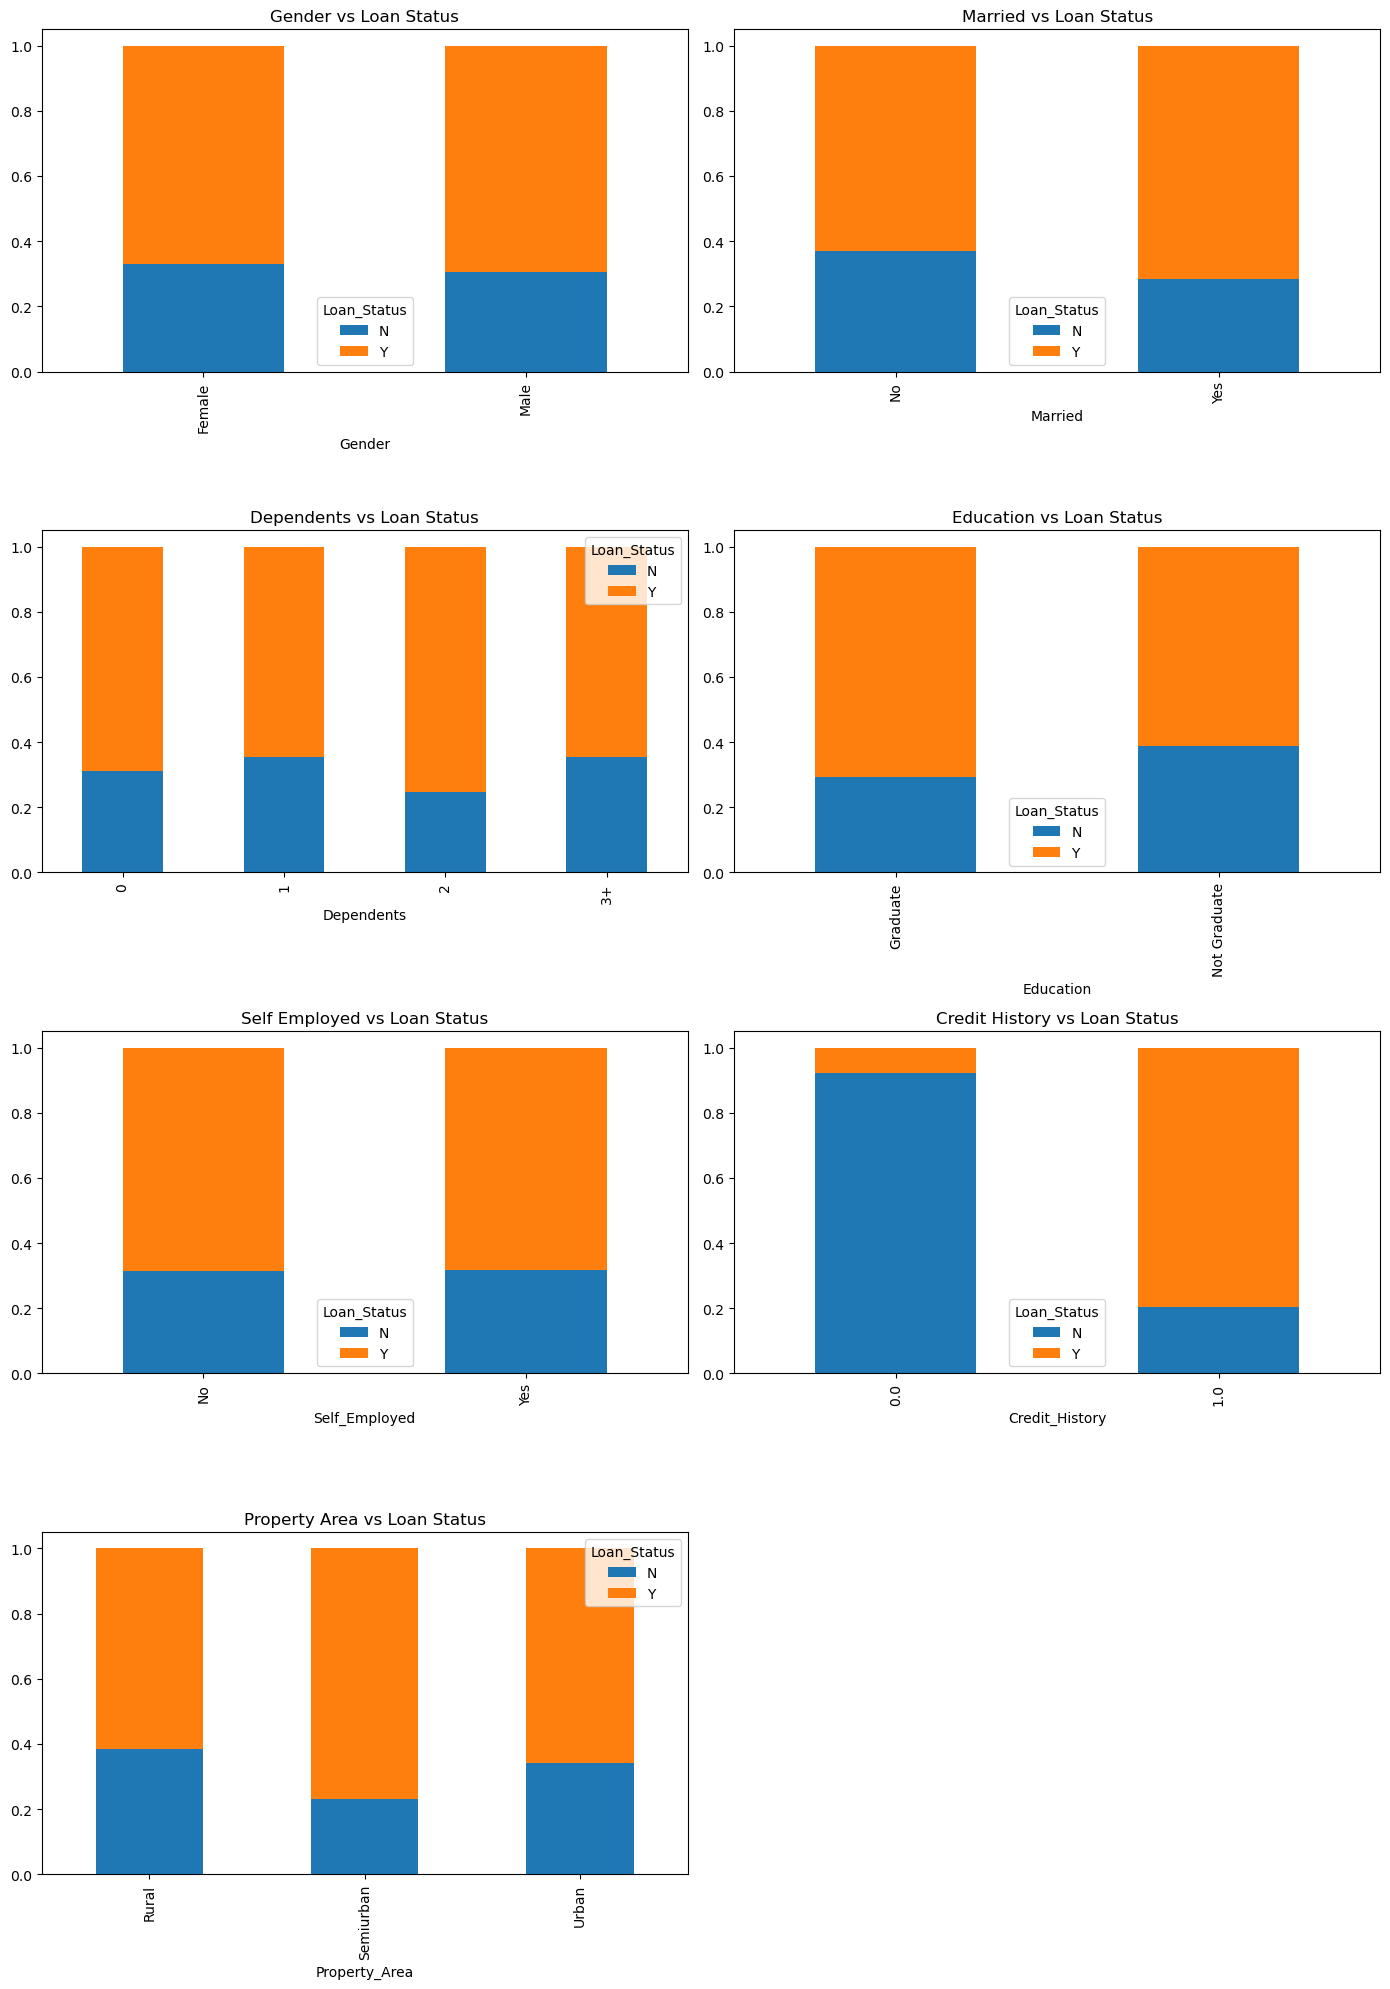

In [1068]:
# Setting up the figure size for a multi-row layout
plt.figure(figsize=(14, 20))

# Gender vs Loan Status
plt.subplot(4, 2, 1)
Gender = pd.crosstab(df['Gender'], df['Loan_Status'])
Gender.div(Gender.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, ax=plt.gca())
plt.title('Gender vs Loan Status')

# Married vs Loan Status
plt.subplot(4, 2, 2)
Married = pd.crosstab(df['Married'], df['Loan_Status'])
Married.div(Married.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, ax=plt.gca())
plt.title('Married vs Loan Status')

# Dependents vs Loan Status
plt.subplot(4, 2, 3)
Dependents = pd.crosstab(df['Dependents'], df['Loan_Status'])
Dependents.div(Dependents.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, ax=plt.gca())
plt.title('Dependents vs Loan Status')

# Education vs Loan Status
plt.subplot(4, 2, 4)
Education = pd.crosstab(df['Education'], df['Loan_Status'])
Education.div(Education.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, ax=plt.gca())
plt.title('Education vs Loan Status')

# Self_Employed vs Loan Status
plt.subplot(4, 2, 5)
Self_Employed = pd.crosstab(df['Self_Employed'], df['Loan_Status'])
Self_Employed.div(Self_Employed.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, ax=plt.gca())
plt.title('Self Employed vs Loan Status')

# Credit_History vs Loan Status
plt.subplot(4, 2, 6)
Credit_History = pd.crosstab(df['Credit_History'], df['Loan_Status'])
Credit_History.div(Credit_History.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, ax=plt.gca())
plt.title('Credit History vs Loan Status')

# Property_Area vs Loan Status
plt.subplot(4, 2, 7)
Property_Area = pd.crosstab(df['Property_Area'], df['Loan_Status'])
Property_Area.div(Property_Area.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, ax=plt.gca())
plt.title('Property Area vs Loan Status')

plt.tight_layout()
plt.show()

In Summary: 
- Credit History: Applicants with a credit history of 1.0 have a significantly higher approval rate, while a score of 0.0 leads to almost certain rejection
- Property Area: Semiurban residents have the highest approval probability compared to Urban and Rural areas
- Education: Graduates are more likely to be approved than non-graduates, indicating education is a key stability metric
- Married Status: Being Married correlates with higher approval rates, likely viewed as a sign of financial reliability
- Dependents: Applicants with 2 dependents show the best approval odds, while those with 1 or 3+ face higher rejection proportions
- Gender & Employment: Both Gender and Self-Employed status show nearly identical approval rates across categories, suggesting minimal impact on the final decision


#### Numerical Independent Variable vs Target Variable

<Axes: xlabel='Loan_Status'>

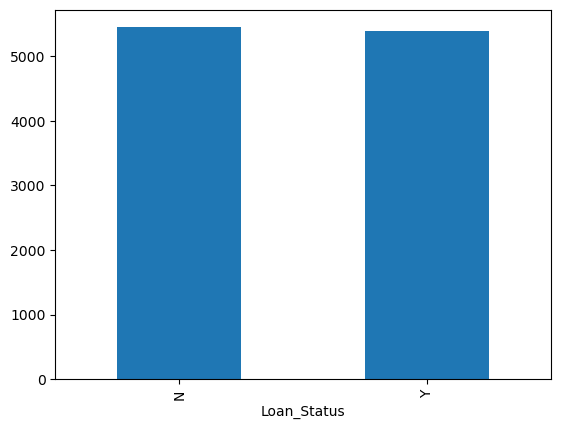

In [1069]:
df.groupby('Loan_Status')['ApplicantIncome'].mean().plot.bar()

Text(0, 0.5, 'Percentage')

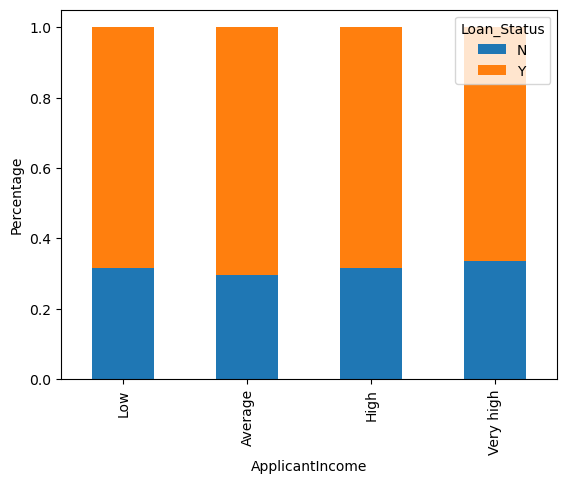

In [1070]:
bins=[0,2500,4000,6000,81000] 
group=['Low','Average','High', 'Very high'] 
df['Income_bin']=pd.cut(df['ApplicantIncome'],bins,labels=group) 
Income_bin=pd.crosstab(df['Income_bin'],df['Loan_Status']) 
Income_bin.div(Income_bin.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True) 
plt.xlabel('ApplicantIncome') 
plt.ylabel('Percentage')

- The above analysis reveals that applicant income does not significantly influence loan approval
- This finding contradicts the initial hypothesis, which assumed that higher earnings would naturally lead to a greater chance of success

Text(0, 0.5, 'Percentage')

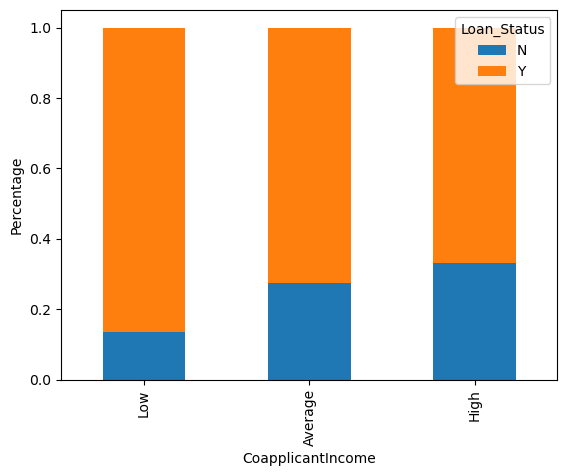

In [1071]:
bins=[0,1000,3000,42000] 
group=['Low','Average','High'] 
df['Coapplicant_Income_bin']=pd.cut(df['CoapplicantIncome'],bins,labels=group) 
Coapplicant_Income_bin=pd.crosstab(df['Coapplicant_Income_bin'],df['Loan_Status']) 
Coapplicant_Income_bin.div(Coapplicant_Income_bin.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True) 
plt.xlabel('CoapplicantIncome')
plt.ylabel('Percentage')

- Low co-applicant income appears to correlate with higher approval rates
- This suggests that individual co-applicant income is not a reliable standalone predictor

Text(0, 0.5, 'Percentage')

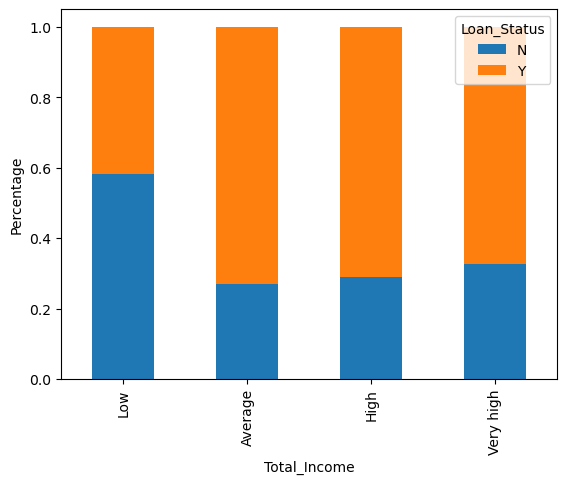

In [1072]:
df['Total_Income']=df['ApplicantIncome']+df['CoapplicantIncome'] 
bins=[0,2500,4000,6000,81000] 
group=['Low','Average','High', 'Very high'] 
df['Total_Income_bin']=pd.cut(df['Total_Income'],bins,labels=group) 
Total_Income_bin=pd.crosstab(df['Total_Income_bin'],df['Loan_Status']) 
Total_Income_bin.div(Total_Income_bin.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True) 
plt.xlabel('Total_Income')
plt.ylabel('Percentage')

- The above plot shows that the Proportion of loans getting approved for applicants having low Total_Income is very less as compared to that of applicants with Average, High and Very High Income

Text(0, 0.5, 'Percentage')

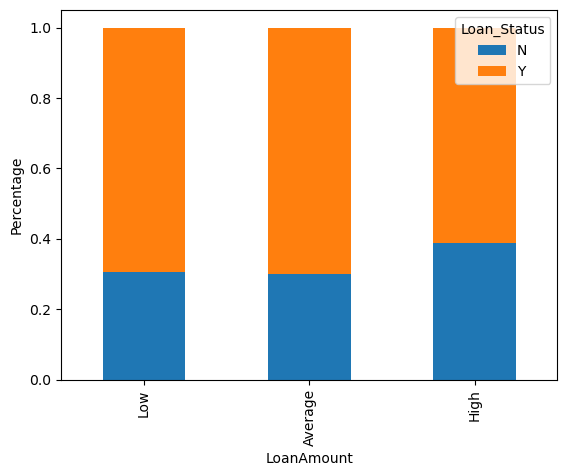

In [1073]:
bins=[0,100,200,700] 
group=['Low','Average','High'] 
df['LoanAmount_bin']=pd.cut(df['LoanAmount'],bins,labels=group) 
LoanAmount_bin=pd.crosstab(df['LoanAmount_bin'],df['Loan_Status']) 
LoanAmount_bin.div(LoanAmount_bin.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True) 
plt.xlabel('LoanAmount')
plt.ylabel('Percentage')

- The analysis indicates that loan approval rates are higher for low and average loan amounts compared to high loan amounts, supporting the hypothesis that smaller requests are more likely to be approved

In [1074]:
# Drop temporary bins used for EDA to prevent redundancy
df=df.drop(['Income_bin', 'Coapplicant_Income_bin', 'LoanAmount_bin', 'Total_Income_bin', 'Total_Income'], axis=1)

# Converts the 'Dependents' categorical values into numerical format by replacing '3+' with 3
df['Dependents'].replace('3+', 3,inplace=True) 


C:\Users\Dell\AppData\Local\Temp\ipykernel_10260\262202138.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dependents'].replace('3+', 3,inplace=True)


In [1075]:
# Target variabl's categories - 0 and 1, to find correlation with numerical variables
df['Loan_Status'].replace('N', 0,inplace=True) 
df['Loan_Status'].replace('Y', 1,inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_10260\3783736937.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Loan_Status'].replace('N', 0,inplace=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_10260\3783736937.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

#### 2.4. Multivariate Analysis
-  Heat Map, visualizes the correlation between all the numerical variables

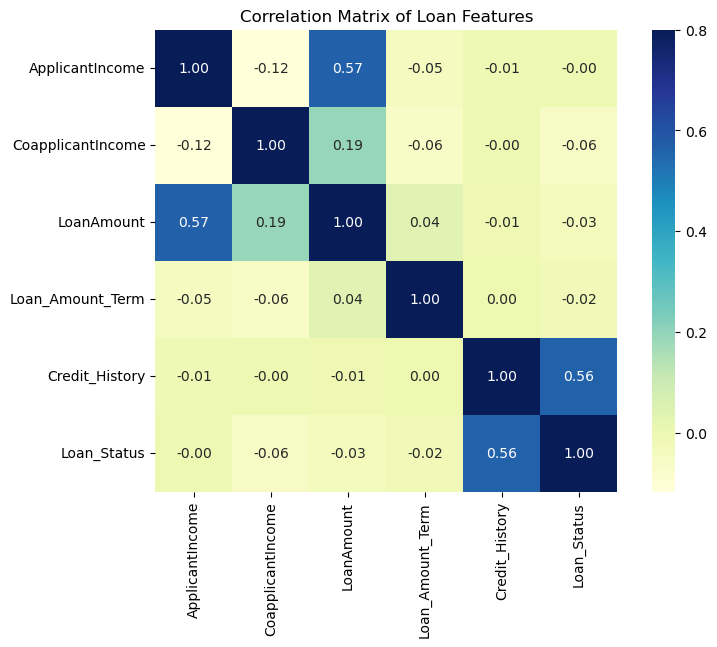

In [1076]:
matrix = df.corr(numeric_only=True)

f, ax = plt.subplots(figsize=(9, 6)) 

sns.heatmap(matrix, 
            vmax=.8, 
            square=True, 
            cmap="YlGnBu", 
            annot=True, # Added annotations to show the numbers
            fmt=".2f");  # Format to 2 decimal places

plt.title("Correlation Matrix of Loan Features")
plt.show()

- It shows that most correlated variables are (ApplicantIncome - LoanAmount) and (Credit_History - Loan_Status)

#### 2.5. Statistical Testing

In [1077]:
for col in categorical_cols:
    if col not in ['Loan_Status', 'Loan_ID']:
        table = pd.crosstab(df[col], df['Loan_Status'])
        # Calculates the p-value to check for statistical significance
        chi2, p, _, _ = chi2_contingency(table)
        # a p-value < 0.05 indicates the feature significantly impacts Loan Status
        print(f"{col} | p-value: {p}")


Gender | p-value: 0.7086529816451106
Married | p-value: 0.03439381301579988
Dependents | p-value: 0.3678506740863235
Education | p-value: 0.04309962129357355
Self_Employed | p-value: 1.0
Property_Area | p-value: 0.0021360187811644937


### 3. Data Analysis and Preprocessing

####  3.1. Handling Missing Values

In [1078]:
# Categorical - Mode
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Numerical - Median
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)


C:\Users\Dell\AppData\Local\Temp\ipykernel_10260\1357099754.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_10260\1357099754.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

In [1079]:
df.isnull().sum()


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

- Missing values were addressed by applying the Mode to categorical features and the Median to numerical ones
- This strategy ensures data completeness while preventing outliers from skewing the distributions.

#### 3.2. Outlier Treatment
- Outlier Impact: Extreme values drastically inflate the mean and standard deviation, distorting the overall data distribution
- Right Skewness: The presence of high-value outliers in LoanAmount causes a long right tail, pushing the bulk of the data to the left.
- Log Transformation: Applying a log scale normalizes the distribution by heavily reducing larger values while maintaining the scale of smaller ones

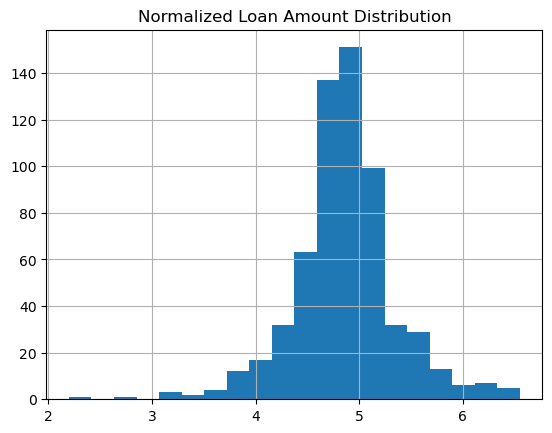

In [1080]:
df['LoanAmount_log'] = np.log(df['LoanAmount'])
df['LoanAmount_log'].hist(bins=20)
plt.title("Normalized Loan Amount Distribution")
plt.show()

- Now the distribution looks much closer to normal and effect of extreme values has been significantly subsided


In [1081]:
# Identify numeric and categorical columns
numerical_cols= df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nThe numerical columns are: {numerical_cols}")
print(f"\nThe categorical columns are: {categorical_cols}")


The numerical columns are: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'LoanAmount_log']

The categorical columns are: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


In [1082]:
# Removing ID column from processing 
if 'Loan_ID' in numerical_cols:
    numerical_cols.remove('Loan_ID')
if 'Loan_ID' in categorical_cols:
    categorical_cols.remove('Loan_ID')

# Removes target variable from feature lists
if 'Loan_Status' in categorical_cols:
    categorical_cols.remove('Loan_Status')

#### 3.3. Feature Engineering
New features are created to better capture the financial health of applicants beyond the raw data:

- EMI Calculation: The EMI variable represents the monthly repayment amount, calculated by dividing the loan amount by the term
- Total Income: ApplicantIncome and CoapplicantIncome were combined to reflect the full household earning power
- Balance Income: This feature measures the remaining monthly liquidity by subtracting the estimated EMI from the Total_Income.

In [1083]:
df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Balance_Income'] = df['Total_Income'] - (df['EMI'] * 1000)


##### Oulier Treatment

C:\Users\Dell\AppData\Local\Temp\ipykernel_10260\2041293919.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Total_Income']);


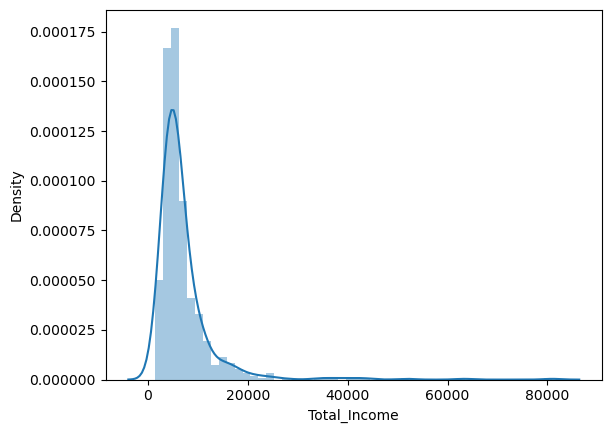

In [1084]:
sns.distplot(df['Total_Income']);

C:\Users\Dell\AppData\Local\Temp\ipykernel_10260\2015311632.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Total_Income_log']);


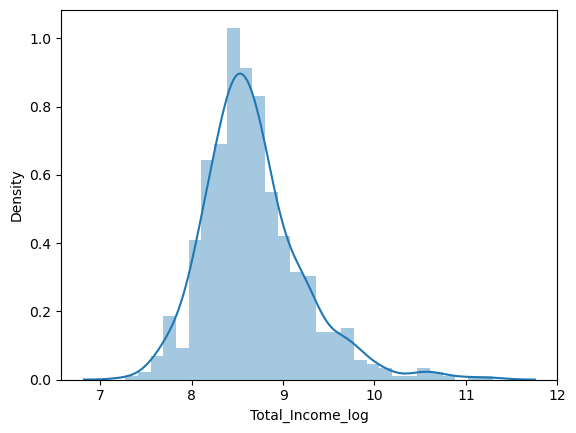

In [1085]:
df['Total_Income_log'] = np.log(df['Total_Income']) 
sns.distplot(df['Total_Income_log']); 


In [1086]:
# Removes redudant raw features
df.drop([
    'Loan_ID','ApplicantIncome','CoapplicantIncome',
    'LoanAmount','Loan_Amount_Term','Total_Income'
], axis=1, inplace=True)


- The above columns were dropped because their information is now captured more effectively by the engineered features EMI, Total_Income, and Balance_Income
- Noise Reduction: The Loan_ID was removed as it is a unique identifier with no predictive power, which helps prevent the model from overfitting on noise
- Multicollinearity Prevention: Dropping the raw inputs used to calculate Balance_Income reduces highly correlated variables, ensuring a more stable and interpretable model

In [1087]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,LoanAmount_log,EMI,Balance_Income,Total_Income_log
0,Male,No,0,Graduate,No,1.0,Urban,1,4.852030,0.355556,5493.444444,8.674026
1,Male,Yes,1,Graduate,No,1.0,Rural,0,4.852030,0.355556,5735.444444,8.714568
2,Male,Yes,0,Graduate,Yes,1.0,Urban,1,4.189655,0.183333,2816.666667,8.006368
3,Male,Yes,0,Not Graduate,No,1.0,Urban,1,4.787492,0.333333,4607.666667,8.505323
4,Male,No,0,Graduate,No,1.0,Urban,1,4.948760,0.391667,5608.333333,8.699515


In [1088]:
df['Loan_Status'].value_counts(dropna=False)


Loan_Status
1    422
0    192
Name: count, dtype: int64

In [1089]:
print(df['Loan_Status'].value_counts())
print(df['Loan_Status'].isnull().sum())



Loan_Status
1    422
0    192
Name: count, dtype: int64
0


In [1090]:
df.shape

(614, 12)

### 4. Train-Test Split
- Training Set (80%): Used to teach the model patterns and relationships between features adn target
- Test Set (20%): Acts as a "final exam" to measure the model’s accuracy and performance on unseen data 

In [1091]:
# Features (X) and Target (y)
X = df.drop('Loan_Status', axis=1)
X = pd.get_dummies(X, drop_first=True)  # encode categorical variables

y = df['Loan_Status'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (614, 14)
y shape: (614,)


In [1092]:
# Split data into training (80%) and testing (20%) sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


SMOTE: 
- Imbalance Correction: Since approved loans significantly outnumbered rejections in the original data, SMOTE is applied to balance the classes
- Model Fairness: By equalizing the classes (50/50 split), the model is less likely to be biased toward approving every application and becomes better at identifying risky loans

In [1093]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)

# Resample ONLY the training data
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {y_train_res.value_counts().to_dict()}")

Before SMOTE: {1: 337, 0: 154}
After SMOTE: {1: 337, 0: 337}


### 5. Model Training

#### Logistic regression Scaling

In [1094]:
scaler = StandardScaler()

# Fits the scaler on the training data and transform it (mean=0, std=1)
X_train_scaled = scaler.fit_transform(X_train_res)

# Applies the same transformation to the test data using training statistics
X_test_scaled = scaler.transform(X_test)


#### Cross- Validation Strategy
- Cross-validation splits the data into multiple folds to ensure the model's accuracy is consistent and not dependent on a single lucky split
- This process helps identify overfitting by averaging performance across different data subsets, leading to a more reliable and stable final model

In [1095]:
# Stratified K-Fold maintains the same class ratio in each fold
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


- Stratified K-Fold, ensures that each data fold contains the same proportion of approved and rejected loans 

### Model 1: Logistic Regression

#### Hyperparameter Tuning

In [1096]:
lr_params = {'C':[0.01, 0.1, 1, 10]}

lr_grid = GridSearchCV(
    LogisticRegression(solver='liblinear'),
    lr_params,
    cv=cv,
    scoring='accuracy'
)

lr_grid.fit(X_train_scaled, y_train_res)

print(f"Logistic Regression Tuning Results")
print(f"Best C Parameter: {lr_grid.best_params_}")
print(f"Mean CV Score (Best): {lr_grid.best_score_:.4f}")

# Extracts SD for the best model
best_index = lr_grid.best_index_
best_std = lr_grid.cv_results_['std_test_score'][best_index]
print(f"Standard Deviation across folds: {best_std:.4f}")

# Get the 5 individual fold scores 
lr_fold_scores = [lr_grid.cv_results_[f'split{i}_test_score'][best_index] for i in range(5)]
for i, score in enumerate(lr_fold_scores):
    print(f"Fold {i+1} Accuracy: {score:.4f}")
lr_best = lr_grid.best_estimator_


Logistic Regression Tuning Results
Best C Parameter: {'C': 0.1}
Mean CV Score (Best): 0.7938
Standard Deviation across folds: 0.0283
Fold 1 Accuracy: 0.8000
Fold 2 Accuracy: 0.8000
Fold 3 Accuracy: 0.7852
Fold 4 Accuracy: 0.7481
Fold 5 Accuracy: 0.8358


- Optimal Regularization: The search identified the best value for C, balancing the model between underfitting and overfitting to maximize generalizability
- Stability Assessment: A low Standard Deviation across the five folds indicates that the model's performance is consistent and not highly sensitive to specific data samples
- Performance Validation: The individual fold scores confirm that the model maintains high accuracy across different subsets, ensuring reliable predictions on unseen data

In [1097]:
lr_pred = lr_best.predict(X_test_scaled)
lr_proba = lr_best.predict_proba(X_test_scaled)[:,1]


### Model 2: Decision Tree

In [1098]:
dt_params = {
    'max_depth':[3,5,7,10,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,5]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=cv,
    scoring='accuracy'
)

dt_grid.fit(X_train_res, y_train_res)

print(f"Decision Tree Tuning Results")
print(f"Best Parameters: {dt_grid.best_params_}")
print(f"Mean CV Score (Best): {dt_grid.best_score_:.4f}")

# Extract best index and SD
best_index_dt = dt_grid.best_index_
best_std_dt = dt_grid.cv_results_['std_test_score'][best_index_dt]
print(f"Standard Deviation across folds: {best_std_dt:.4f}")

# Print individual fold accuracies
for i in range(5):
    fold_score = dt_grid.cv_results_[f'split{i}_test_score'][best_index_dt]
    print(f"Fold {i+1} Accuracy: {fold_score:.4f}")

dt_best = dt_grid.best_estimator_

dt_pred = dt_best.predict(X_test)
dt_proba = dt_best.predict_proba(X_test)[:,1]

# To see the mean score and standard deviation across 5 folds:
print(f"Mean CV Score: {rf_grid.best_score_}")
print(f"Detailed Results per fold: {rf_grid.cv_results_['mean_test_score']}")


Decision Tree Tuning Results
Best Parameters: {'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2}
Mean CV Score (Best): 0.7879
Standard Deviation across folds: 0.0431
Fold 1 Accuracy: 0.8296
Fold 2 Accuracy: 0.7111
Fold 3 Accuracy: 0.7852
Fold 4 Accuracy: 0.7852
Fold 5 Accuracy: 0.8284
Mean CV Score: 0.8205417357656165
Detailed Results per fold: [0.7893864  0.7938419  0.79681592 0.79977888 0.78641238 0.79381979
 0.79679381 0.79679381 0.81460475 0.81164179 0.82054174 0.8145937
 0.79531233 0.8012272  0.79529022 0.79678275 0.81165285 0.80573798
 0.81017137 0.80571587 0.8072084  0.79682698 0.79233831 0.79825318]


- A 78.79% Mean CV score demonstrates strong predictive power, though a standard deviation of 0.0431 suggests some sensitivity to specific data splits across the folds

### Model 3: Random Forest

In [1099]:
rf_params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train_res, y_train_res)

print(f"Random Forest Tuning Results")
print(f"Best Parameters: {rf_grid.best_params_}")
print(f"Best Mean Cross-Validation Score: {rf_grid.best_score_:.4f}")

# Extract best index and SD
best_index_rf = rf_grid.best_index_
best_std_rf = rf_grid.cv_results_['std_test_score'][best_index_rf]
print(f"Standard Deviation across 5 folds: {best_std_rf:.4f}")

# Prints individual fold accuracies
for i in range(5):
    fold_score = rf_grid.cv_results_[f'split{i}_test_score'][best_index_rf]
    print(f"Fold {i+1} Accuracy: {fold_score:.4f}")


rf_best = rf_grid.best_estimator_

rf_pred = rf_best.predict(X_test)
rf_proba = rf_best.predict_proba(X_test)[:,1]




Random Forest Tuning Results
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Mean Cross-Validation Score: 0.8205
Standard Deviation across 5 folds: 0.0382
Fold 1 Accuracy: 0.8593
Fold 2 Accuracy: 0.7630
Fold 3 Accuracy: 0.8148
Fold 4 Accuracy: 0.8000
Fold 5 Accuracy: 0.8657


- Top Performance: Achieved the highest Mean CV Score (82.05%), proving that the ensemble approach is more effective than a single decision tree or linear model

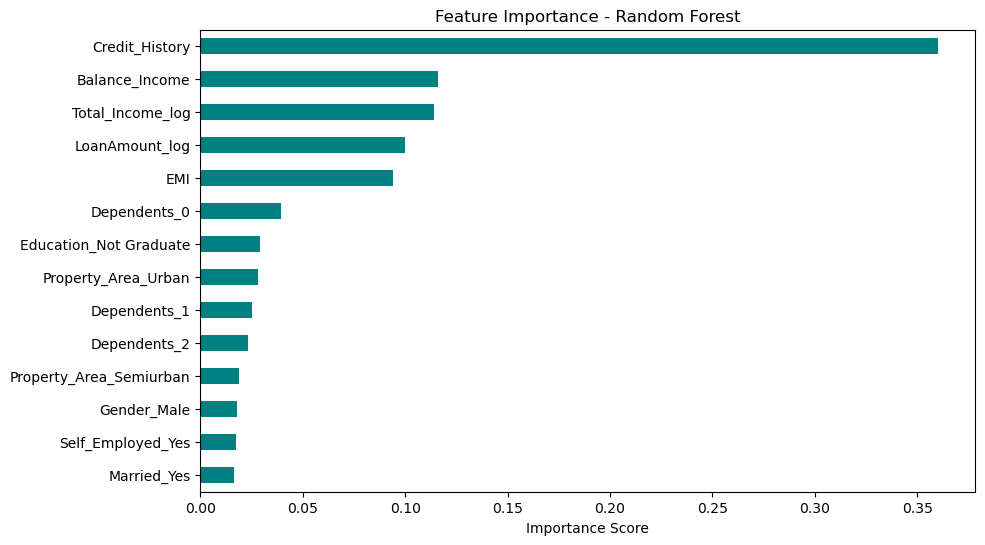

In [1100]:
# Feature Importance for Random Forest
importances = pd.Series(rf_best.feature_importances_, index=X.columns)
plt.figure(figsize=(10,6))
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.show()

### 6. Comparision Metric

In [1101]:
def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1_Score': f1_score(y_true, y_pred),
        'ROC_AUC': roc_auc_score(y_true, y_proba)
    }


In [1102]:
results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, lr_pred, lr_proba),
    evaluate_model("Decision Tree", y_test, dt_pred, dt_proba),
    evaluate_model("Random Forest", y_test, rf_pred, rf_proba)
])

results.sort_values(by='Accuracy', ascending=False)


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.821138,0.831579,0.929412,0.877778,0.747368
2,Random Forest,0.804878,0.835165,0.894118,0.863636,0.789474
1,Decision Tree,0.764228,0.825581,0.835294,0.830409,0.794582


### 7. Evaluation

### Confusion Matrix

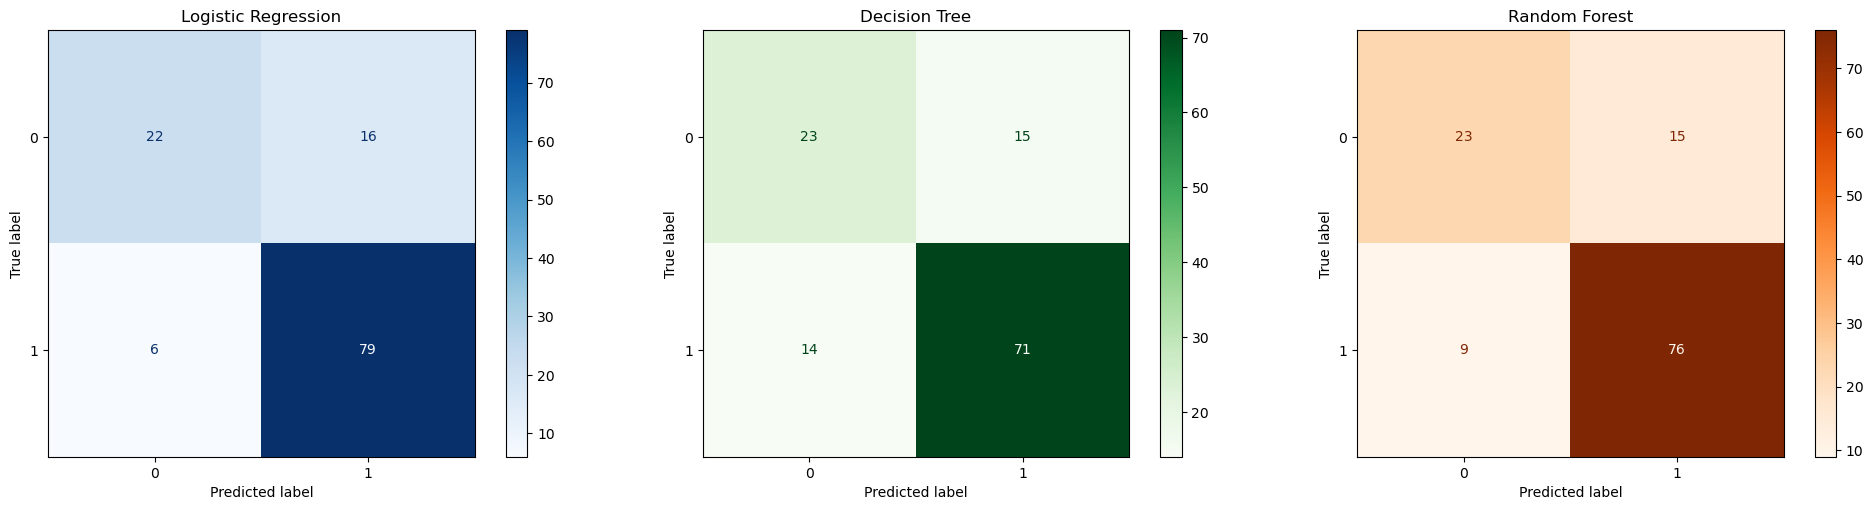

In [1103]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Logistic Regression
ConfusionMatrixDisplay.from_estimator(lr_best, X_test_scaled, y_test, ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression')

# Decision Tree
ConfusionMatrixDisplay.from_estimator(dt_best, X_test, y_test, ax=axes[1], cmap='Greens')
axes[1].set_title('Decision Tree')

# Random Forest
ConfusionMatrixDisplay.from_estimator(rf_best, X_test, y_test, ax=axes[2], cmap='Oranges')
axes[2].set_title('Random Forest')

plt.tight_layout()
plt.show()

### Precison-Recall Curve

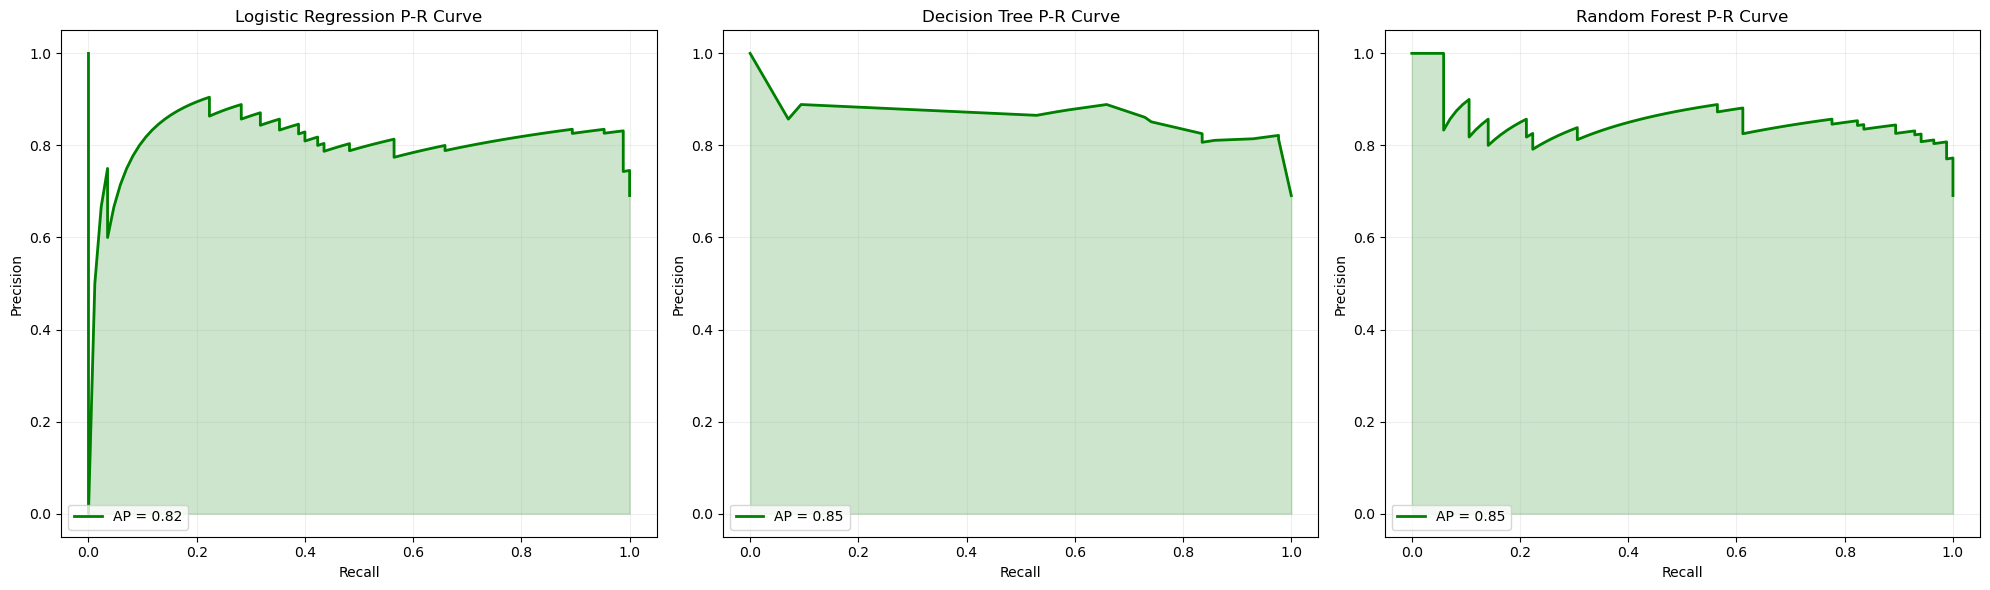

In [1104]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (name, model, xtest) in enumerate(models):
    probs = model.predict_proba(xtest)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, probs)
    avg_prec = average_precision_score(y_test, probs)
    
    axes[i].plot(recall, precision, color='green', lw=2, label=f'AP = {avg_prec:.2f}')
    axes[i].fill_between(recall, precision, alpha=0.2, color='green')
    axes[i].set_title(f'{name} P-R Curve')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].legend(loc="lower left")
    axes[i].grid(alpha=0.2)

plt.tight_layout()
plt.show()

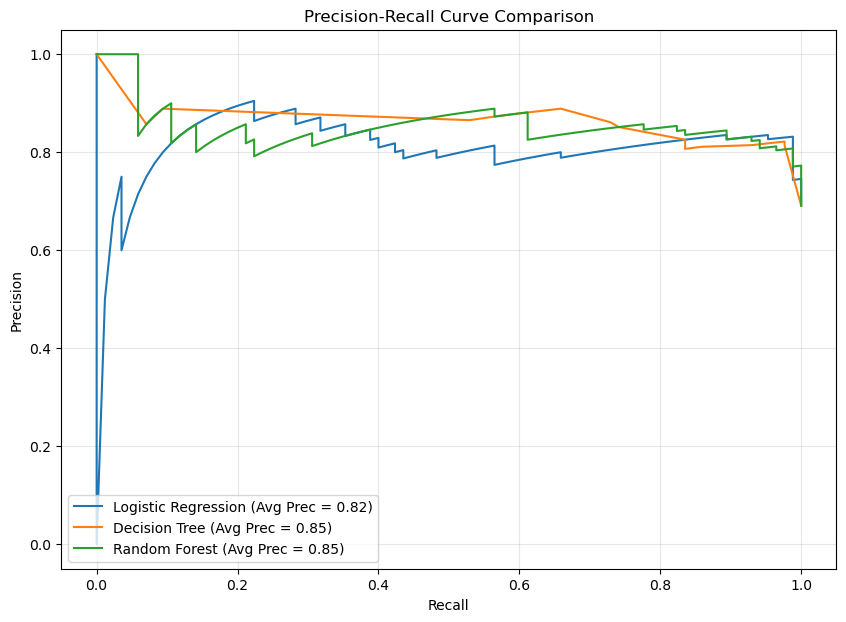

In [1105]:
plt.figure(figsize=(10, 7))

for name, model, xtest in models:
    probs = model.predict_proba(xtest)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, probs)
    avg_prec = average_precision_score(y_test, probs)
    
    plt.plot(recall, precision, label=f'{name} (Avg Prec = {avg_prec:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()

### ROC-Curve

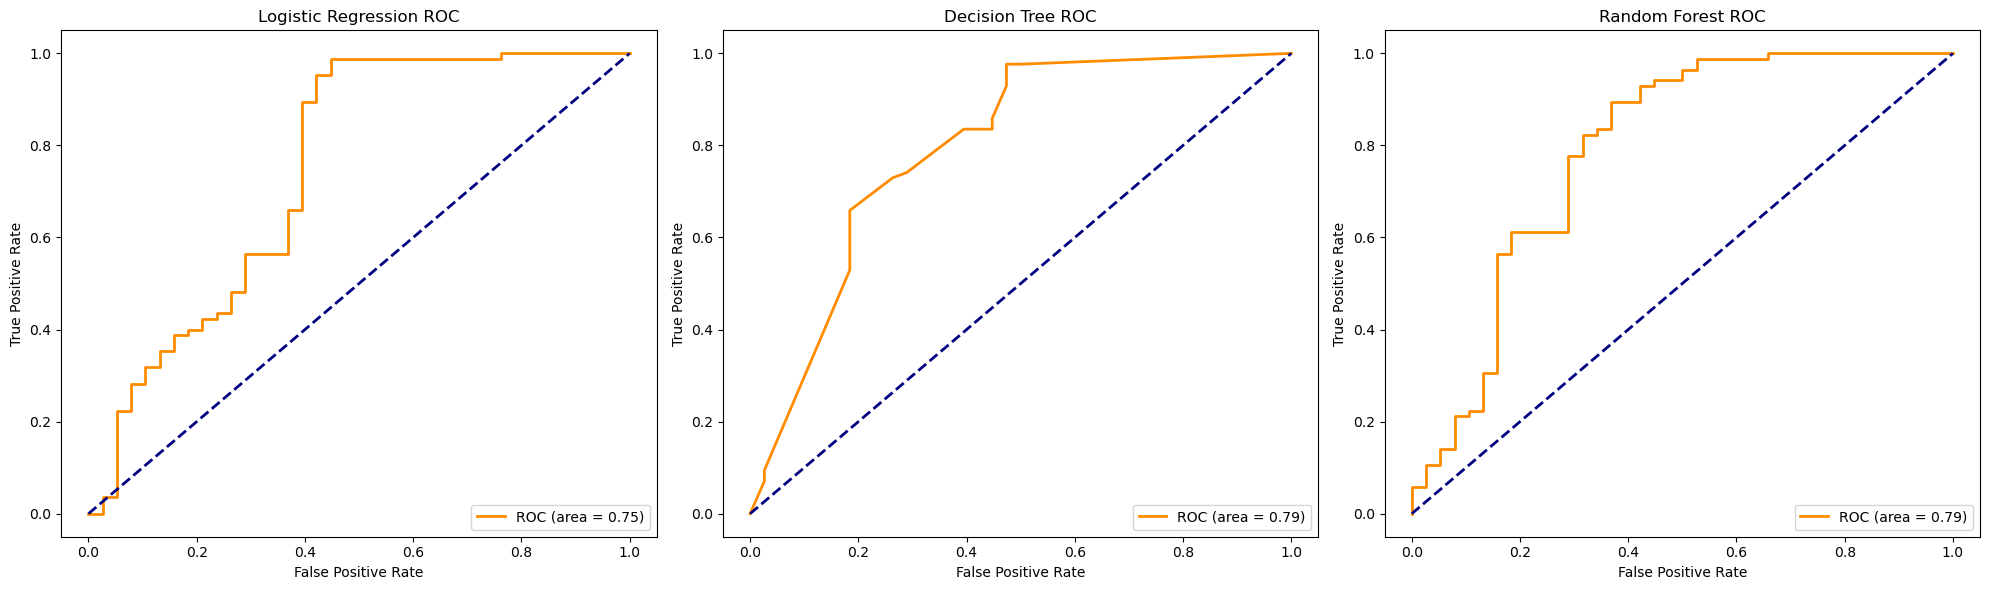

In [1106]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
models = [
    ('Logistic Regression', lr_best, X_test_scaled),
    ('Decision Tree', dt_best, X_test),
    ('Random Forest', rf_best, X_test)
]

for i, (name, model, xtest) in enumerate(models):
    probs = model.predict_proba(xtest)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    
    axes[i].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (area = {roc_auc:.2f})')
    axes[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[i].set_title(f'{name} ROC')
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(loc="lower right")

plt.tight_layout()
plt.show()

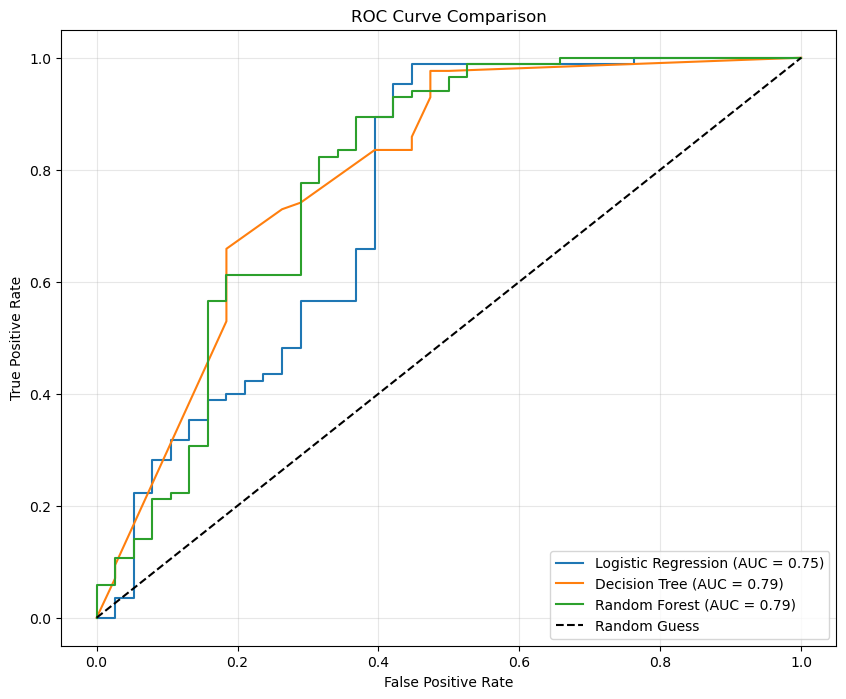

In [1107]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# Define models and their test data (scaled for LR, unscaled for others)
models = [
    ('Logistic Regression', lr_best, X_test_scaled),
    ('Decision Tree', dt_best, X_test),
    ('Random Forest', rf_best, X_test)
]

for name, model, xtest in models:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(xtest)[:,1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

### 8. Sample Prediction

In [1108]:
# Creating a sample applicant 
sample_data = pd.DataFrame({
    'Credit_History': [1.0],
    'LoanAmount_log': [np.log(150)], 
    'EMI': [150/360],
    'Balance_Income': [3000 - (150/360)*1000],
    'Total_Income_log': [np.log(4500)],
    'Gender_Male': [1],
    'Married_Yes': [1],
    'Dependents_0': [0], 
    'Dependents_1': [0],
    'Dependents_2': [1],
    'Education_Not Graduate': [0],
    'Self_Employed_Yes': [0],
    'Property_Area_Semiurban': [1],
    'Property_Area_Urban': [0]
})

sample_data = sample_data[X_train.columns]



In [1109]:
# Scales the sample for Logistic Regression
sample_scaled = scaler.transform(sample_data)

# Logistic Regression Prediction
lr_samp_pred = lr_best.predict(sample_scaled)[0]
lr_samp_prob = lr_best.predict_proba(sample_scaled)[0][1]

# Decision Tree Prediction
dt_samp_pred = dt_best.predict(sample_data)[0]
dt_samp_prob = dt_best.predict_proba(sample_data)[0][1]

# Random Forest Prediction
rf_samp_pred = rf_best.predict(sample_data)[0]
rf_samp_prob = rf_best.predict_proba(sample_data)[0][1]

print(f"Sample Applicant Prediction Results ")
print(f"Logistic Regression: {'Approved' if lr_samp_pred==1 else 'Rejected'} (Prob: {lr_samp_prob:.2f})")
print(f"Decision Tree:       {'Approved' if dt_samp_pred==1 else 'Rejected'} (Prob: {dt_samp_prob:.2f})")
print(f"Random Forest:       {'Approved' if rf_samp_pred==1 else 'Rejected'} (Prob: {rf_samp_prob:.2f})")

Sample Applicant Prediction Results 
Logistic Regression: Approved (Prob: 0.84)
Decision Tree:       Approved (Prob: 0.83)
Random Forest:       Approved (Prob: 0.84)


In [1110]:
# Creates a high-risk sample applicant to check negative prediction
high_risk_sample = pd.DataFrame({
    'Credit_History': [0.0],          # Bad Credit History
    'LoanAmount_log': [np.log(400)],  # Very high loan request 
    'EMI': [400/360],
    'Balance_Income': [8000 - (400/360)*1000], # High income but risky
    'Total_Income_log': [np.log(8000)],
    'Gender_Male': [1],
    'Married_Yes': [1],
    'Dependents_0': [0],
    'Dependents_1': [0],
    'Dependents_2': [1],
    'Education_Not Graduate': [0],
    'Self_Employed_Yes': [1],         # Self-employed (often considered higher risk)
    'Property_Area_Semiurban': [0],
    'Property_Area_Urban': [1]
})

high_risk_sample = high_risk_sample[X_train.columns]

In [1111]:
# Scales for Logistic Regression
high_risk_scaled = scaler.transform(high_risk_sample)

# Predictions & Probabilities
lr_neg_pred = lr_best.predict(high_risk_scaled)[0]
lr_neg_prob = lr_best.predict_proba(high_risk_scaled)[0][1]

rf_neg_pred = rf_best.predict(high_risk_sample)[0]
rf_neg_prob = rf_best.predict_proba(high_risk_sample)[0][1]

dt_neg_pred = dt_best.predict(high_risk_sample)[0]
dt_neg_prob = dt_best.predict_proba(high_risk_sample)[0][1]

print(f"High-Risk Sample Results")
print(f"Logistic Regression: {'Approved' if lr_neg_pred==1 else 'Rejected'} (Prob: {lr_neg_prob:.2f})")
print(f"Decision Tree:       {'Approved' if dt_neg_pred==1 else 'Rejected'} (Prob: {dt_neg_prob:.2f})")
print(f"Random Forest:       {'Approved' if rf_neg_pred==1 else 'Rejected'} (Prob: {rf_neg_prob:.2f})")

High-Risk Sample Results
Logistic Regression: Rejected (Prob: 0.05)
Decision Tree:       Rejected (Prob: 0.00)
Random Forest:       Rejected (Prob: 0.25)
